In [78]:
import yfinance as yf
import pandas as pd
import numpy as np


In [79]:
ticker = "GC=F"

In [80]:
df = yf.download(ticker, start = "2025-01-01",end = "2026-03-01", interval = "1d", auto_adjust=True, progress=False)

In [81]:
df = df.dropna()

In [82]:
df

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2025-01-02,2658.899902,2663.100098,2633.000000,2633.000000,1728
2025-01-03,2645.000000,2658.699951,2641.800049,2658.699951,591
2025-01-06,2638.399902,2647.000000,2617.300049,2645.500000,960
2025-01-07,2656.699951,2657.500000,2653.000000,2653.399902,643
2025-01-08,2664.500000,2676.899902,2653.500000,2655.500000,999
...,...,...,...,...,...
2026-02-23,5204.700195,5211.600098,5120.299805,5120.299805,779
2026-02-24,5155.799805,5159.000000,5112.700195,5158.799805,88


In [89]:
price = df["Close"].copy()

In [90]:
price

Ticker,GC=F
Date,
2025-01-02,2658.899902
2025-01-03,2645.000000
2025-01-06,2638.399902
2025-01-07,2656.699951
2025-01-08,2664.500000
...,...
2026-02-23,5204.700195
2026-02-24,5155.799805
2026-02-25,5206.399902


In [92]:
price.name = "price"

In [93]:
log_price = np.log(price)
log_return = log_price.diff().dropna()
log_return.name = "log_return"

print(df.head())

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2025-01-02  2658.899902  2663.100098  2633.000000  2633.000000   1728
2025-01-03  2645.000000  2658.699951  2641.800049  2658.699951    591
2025-01-06  2638.399902  2647.000000  2617.300049  2645.500000    960
2025-01-07  2656.699951  2657.500000  2653.000000  2653.399902    643
2025-01-08  2664.500000  2676.899902  2653.500000  2655.500000    999


In [95]:
print(df.shape)

(291, 5)


In [96]:
price.head()

Ticker,GC=F
Date,
2025-01-02,2658.899902
2025-01-03,2645.000000
2025-01-06,2638.399902
2025-01-07,2656.699951
2025-01-08,2664.500000


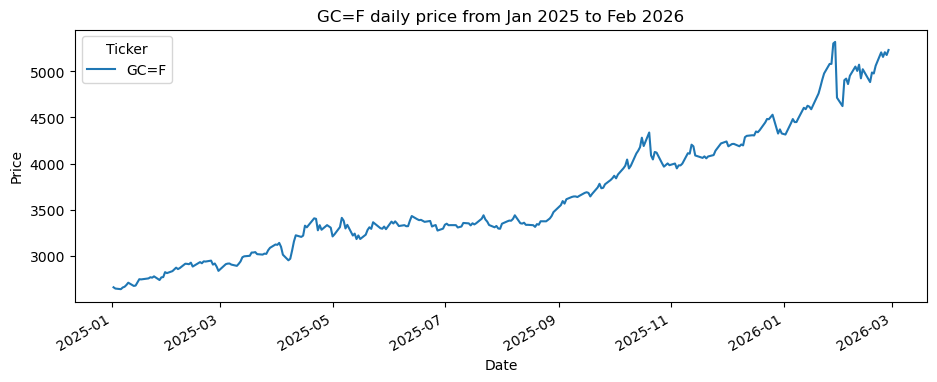

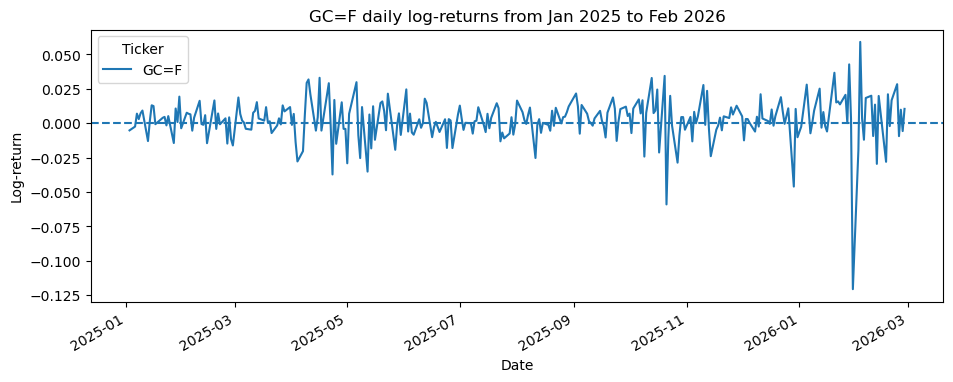

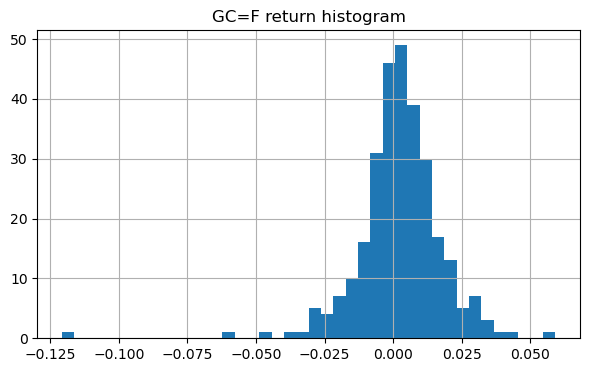

In [98]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
price.plot(ax=ax, title=f"{ticker} daily price from Jan 2025 to Feb 2026")
ax.set_ylabel("Price")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
log_return.plot(ax=ax, title=f"{ticker} daily log-returns from Jan 2025 to Feb 2026")
ax.axhline(0, linestyle="--")
ax.set_ylabel("Log-return")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
log_return.hist(ax=ax, bins=40)
ax.set_title(f"{ticker} return histogram")
plt.show()

**Response** :
1. The gold plot during the period shows a very strong upward trend, so the series is clearly not stationary in level. Visually, price rises from roughly 2,650 in Jaunary 2025 to above 5,200 by March 2026, with a few short pullbacks but no sustained reversal. 
2. 

In [99]:
summary = pd.DataFrame({
    "mean": [log_return.mean()],
    "std": [log_return.std()],
    "skew": [log_return.skew()],
    "kurtosis": [log_return.kurtosis()],
    "min": [log_return.min()],
    "max": [log_return.max()]
})

print(summary)

                                     mean  \
0  Ticker
GC=F    0.002333
dtype: float64   

                                      std  \
0  Ticker
GC=F    0.015646
dtype: float64   

                                    skew  \
0  Ticker
GC=F   -1.82044
dtype: float64   

                                  kurtosis  \
0  Ticker
GC=F    13.885448
dtype: float64   

                                      min  \
0  Ticker
GC=F   -0.120657
dtype: float64   

                                      max  
0  Ticker
GC=F    0.059054
dtype: float64  


# ADF stationary test

#### This test checks for a unit root. A series is roughly stationary if its statistical behavior stays stable over time: mean does not drift, variance is relatively stable, dependence structure does not keep changing. 

In [100]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name, regression="c"):
    result = adfuller(series.dropna(), regression=regression, autolag="AIC")
    print(f"\nADF test for {name}")
    print(f"Test statistic: {result[0]:.4f}")
    print(f"p-value       : {result[1]:.40f}")
    print(f"Used lags     : {result[2]}")
    print(f"N observations: {result[3]}")
    print("Critical values:")
    for k, v in result[4].items():
        print(f"   {k}: {v:.4f}")

adf_report(price, f"{ticker} price")
adf_report(log_return, f"{ticker} log-return")


ADF test for GC=F price
Test statistic: 0.6348
p-value       : 0.9884431638735503566906004380143713206053
Used lags     : 2
N observations: 288
Critical values:
   1%: -3.4533
   5%: -2.8716
   10%: -2.5721

ADF test for GC=F log-return
Test statistic: -13.9648
p-value       : 0.0000000000000000000000000445230272441353
Used lags     : 1
N observations: 288
Critical values:
   1%: -3.4533
   5%: -2.8716
   10%: -2.5721


**Response**: 
The augmented Dicked-Fuller test indicates that the GC=F price series is non-stationary in levels. The p-value from the test is 0.988443. So, the null hypothesis of a unit root cannot be rejected,confirming that the price series is non-stationary. In constrast, the log-return series is stationary. The ADF test is order of magnitude ~10e-6. Hence, the null hypothesis of a unit root is strongly rejected for log-returns. This result suggests that while the gold price series itself is non-stationary, its log-returns are stationary and therefore more suitable for our time-series modeling.

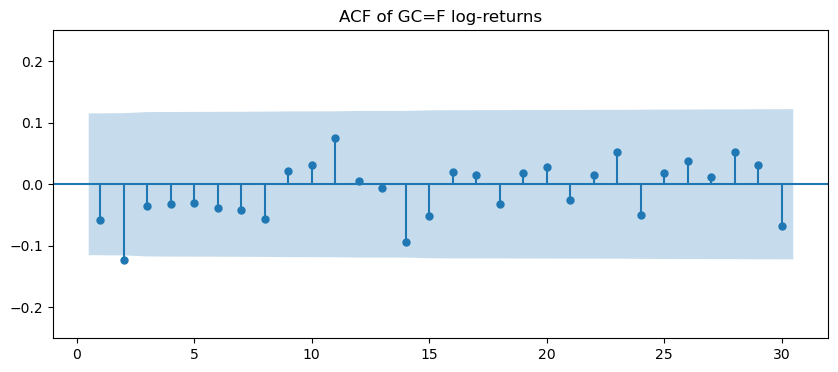

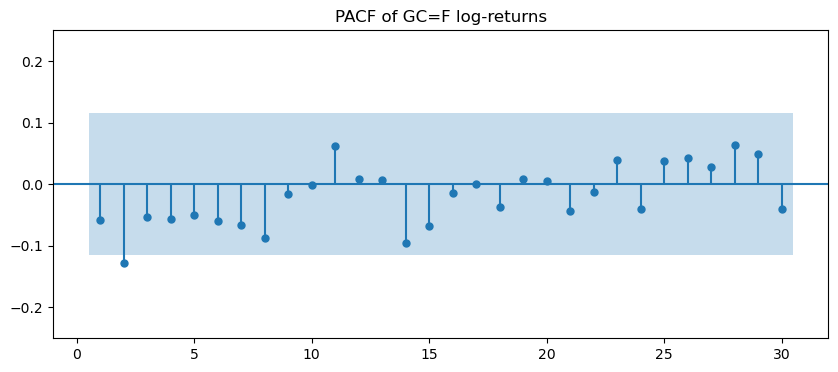

In [101]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(log_return, lags=30, ax=ax, zero=False)
ax.set_title(f"ACF of {ticker} log-returns")
ax.set_ylim(-0.25, 0.25)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(log_return, lags=30, ax=ax, method="ywm", zero=False)
ax.set_title(f"PACF of {ticker} log-returns")
ax.set_ylim(-0.25, 0.25)
plt.show()


**Response**: 
The fact that most autocorrelation coefficients lie within the 95% confidence intervals indicates that the GC=F log-return series exhibits little linear serial dependence. Hence, the series may be regarded as approximately white noise in the conditional mean, implying limited predictability from its own past values.

In [102]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(log_return, lags=[10, 20,30], return_df=True)


,lb_stat,lb_pvalue
10,8.794487,0.551712
20,14.866935,0.783970
30,20.061500,0.914930


**Response**: The Ljung-Box test was applied to the GC=F log-return series at lags 10, 20, and 30. The resulting p-values (0.5517, 0.7840, and 0.9149) are all greater than 0.05, so the null hypothesis of no autocorrelation cannot be rejected. This indicates that the log-return series does not exhibit significant linear serial correlation and behaves approximately like white noise in the mean

In [104]:
log_return

Ticker,GC=F
Date,
2025-01-03,-0.005241
2025-01-06,-0.002498
2025-01-07,0.006912
2025-01-08,0.002932
2025-01-09,0.007217
...,...
2026-02-23,0.028334
2026-02-24,-0.009440
2026-02-25,0.009766


In [103]:
from statsmodels.tsa.arima.model import ARIMA

mean_model = ARIMA(log_return, order=(1, 0, 1))
mean_res = mean_model.fit()

print(mean_res.summary())

                               SARIMAX Results                                
Dep. Variable:                   GC=F   No. Observations:                  290
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 799.702
Date:                Sun, 22 Mar 2026   AIC                          -1591.404
Time:                        09:54:19   BIC                          -1576.725
Sample:                             0   HQIC                         -1585.523
                                - 290                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      4.017      0.000       0.001       0.003
ar.L1          0.7505      0.082      9.176      0.000       0.590       0.911
ma.L1         -0.8745      0.063    -13.805      0.0

In [105]:
from scipy.stats import jarque_bera

def jb_report(series, name):
    jb_stat, jb_pvalue = jarque_bera(series.dropna())
    print(f"\nJarque-Bera test for {name}")
    print(f"JB statistic: {jb_stat:.4f}")
    print(f"p-value     : {jb_pvalue:.6f}")
    if jb_pvalue < 0.05:
        print("Reject H0 of normality.")
    else:
        print("Fail to reject H0 of normality.")

jb_report(log_return, f"{ticker} log-returns")
jb_report(mean_res.resid, f"{ticker} ARIMA(1,0,1) residuals")



Jarque-Bera test for GC=F log-returns
JB statistic: 2402.1988
p-value     : 0.000000
Reject H0 of normality.

Jarque-Bera test for GC=F ARIMA(1,0,1) residuals
JB statistic: 1353.9975
p-value     : 0.000000
Reject H0 of normality.


**Response**: The Jarque-Bera test strongly rejects the null hypothesis of normality for both the `GC=F` log-return series and the `ARIMA(1,0,1)` residuals. This indicates that the data are not normally distributed and exhibit departures such as skewness and excess kurtosis. Consequently, a Gaussian error assumption is not well supported by the data, and heavier-tailed specifications should be considered for volatility modeling.

### Next Step After Jarque-Bera

The Jarque-Bera test tells us that the returns and mean-model residuals are not normally distributed, but it does not tell us whether volatility changes over time. The next diagnostic step is to test for `ARCH` effects in the residuals. If this test is significant, then a `GARCH`-type model is appropriate for capturing time-varying volatility.

In [106]:
from statsmodels.stats.diagnostic import het_arch

def arch_lm_report(series, name, nlags=10):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(series.dropna(), nlags=nlags)
    print(f"\nARCH-LM test for {name} (lags={nlags})")
    print(f"LM statistic: {lm_stat:.4f}")
    print(f"LM p-value  : {lm_pvalue:.6f}")
    print(f"F statistic : {f_stat:.4f}")
    print(f"F p-value   : {f_pvalue:.6f}")

arch_lm_report(mean_res.resid, f"{ticker} ARIMA(1,0,1) residuals", nlags=10)



ARCH-LM test for GC=F ARIMA(1,0,1) residuals (lags=10)
LM statistic: 27.9768
LM p-value  : 0.001821
F statistic : 2.9861
F p-value   : 0.001376


**Response**: The `ARCH-LM` test on the `ARIMA(1,0,1)` residuals is significant (`LM = 27.9768`, `p = 0.001821`; `F = 2.9861`, `p = 0.001376`). Therefore, the null hypothesis of no ARCH effects is rejected. This indicates volatility clustering in the residuals and justifies moving to a conditional variance model such as `GARCH(1,1)`.

### GARCH(1,1) With Student-t Errors

Since the Jarque-Bera test rejected normality, a heavy-tailed distribution is more appropriate than Gaussian errors. We therefore fit a `GARCH(1,1)` model to percentage log-returns (`100 * log_return`) using both normal and Student-t innovations, and compare their information criteria. The percentage scaling improves numerical stability without changing the time-series interpretation.

In [109]:
from arch import arch_model

returns_pct = 100 * log_return

garch11_normal = arch_model(returns_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
garch11_normal_res = garch11_normal.fit(disp="off")

garch11_t = arch_model(returns_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="studentst")
garch11_res = garch11_t.fit(disp="off")

comparison = pd.DataFrame(
    {
        "AIC": [garch11_normal_res.aic, garch11_res.aic],
        "BIC": [garch11_normal_res.bic, garch11_res.bic],
        "loglikelihood": [garch11_normal_res.loglikelihood, garch11_res.loglikelihood],
    },
    index=["GARCH(1,1)-Normal", "GARCH(1,1)-Student-t"],
)

print(comparison.round(4))
print()
print(garch11_res.summary())


                            AIC        BIC  loglikelihood
GARCH(1,1)-Normal     1013.9352  1028.6147      -502.9676
GARCH(1,1)-Student-t   978.5308   996.8802      -484.2654

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         GC=F   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -484.265
Distribution:      Standardized Student's t   AIC:                           978.531
Method:                  Maximum Likelihood   BIC:                           996.880
                                              No. Observations:                  290
Date:                      Sun, Mar 22 2026   Df Residuals:                      289
Time:                              10:28:33   Df Model:                            1
                               Mean Model                   

In [113]:
garch11_res

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         GC=F   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -484.265
Distribution:      Standardized Student's t   AIC:                           978.531
Method:                  Maximum Likelihood   BIC:                           996.880
                                              No. Observations:                  290
Date:                      Sun, Mar 22 2026   Df Residuals:                      289
Time:                              10:28:33   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

**Response**: The `Student-t` specification improves the fit relative to the Gaussian version (`AIC = 978.5308` versus `1013.9352`). In the selected `GARCH(1,1)` model, both `alpha[1] = 0.1363` and `beta[1] = 0.8133` are significant, and their sum (`0.9496`) indicates strong volatility persistence. This means that volatility shocks are long-lasting but still mean-reverting. The estimated degrees of freedom parameter (`nu = 4.1419`) confirms heavy tails, which is consistent with the earlier Jarque-Bera result.

In [114]:
garch11_res.std_resid

Date
2025-01-03   -0.906053
2025-01-06   -0.565768
2025-01-07    0.443550
2025-01-08    0.019084
2025-01-09    0.482294
                ...   
2026-02-23    1.184391
2026-02-24   -0.554925
2026-02-25    0.339418
2026-02-26   -0.443667
2026-02-27    0.424029
Name: std_resid, Length: 290, dtype: float64

In [115]:
garch11_res.conditional_volatility

Date
2025-01-03    0.882296
2025-01-06    0.928136
2025-01-07    0.937760
2025-01-08    0.938079
2025-01-09    0.925707
                ...   
2026-02-23    2.159873
2026-02-24    2.197147
2026-02-25    2.066391
2026-02-26    1.918584
2026-02-27    1.798238
Name: cond_vol, Length: 290, dtype: float64

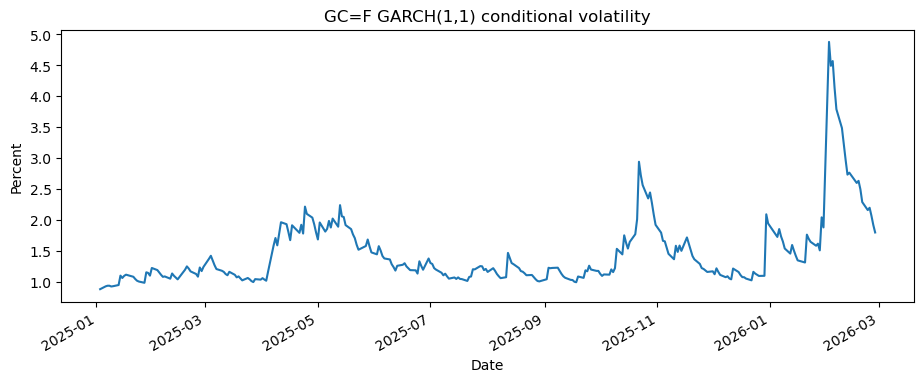

    lb_stat  lb_pvalue
10   7.5478     0.6729
20  11.4203     0.9346

    lb_stat  lb_pvalue
10   7.6780     0.6603
20  10.3867     0.9606


ARCH-LM test for GC=F GARCH standardized residuals (lags=10)
LM statistic: 7.0093
LM p-value  : 0.724565
F statistic : 0.6907
F p-value   : 0.732928


In [110]:
std_resid = garch11_res.std_resid.dropna()

fig, ax = plt.subplots(figsize=(11, 4))
garch11_res.conditional_volatility.rename("Conditional volatility (%)").plot(ax=ax)
ax.set_title(f"{ticker} GARCH(1,1) conditional volatility")
ax.set_ylabel("Percent")
plt.show()

print(acorr_ljungbox(std_resid, lags=[10, 20], return_df=True).round(4))
print()
print(acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True).round(4))
print()
arch_lm_report(std_resid, f"{ticker} GARCH standardized residuals", nlags=10)


**Response**: After fitting the `Student-t GARCH(1,1)` model, the standardized residual diagnostics no longer show significant serial correlation or remaining ARCH effects. The Ljung-Box p-values for standardized residuals are `0.6729` and `0.9346` at lags 10 and 20, while the p-values for squared standardized residuals are `0.6603` and `0.9606`. In addition, the `ARCH-LM` test on standardized residuals is not significant (`p = 0.7246`). These results suggest that the fitted GARCH model captures the main volatility clustering in the series.

### Next Step for March 2026 Forecasting

At this point, the return series shows weak mean predictability but clear time-varying volatility. The next modeling step is to generate `March 2026` forecasts by combining a simple mean forecast for log-returns with the fitted `GARCH(1,1)` volatility forecast, and then converting the cumulative predicted returns back into forecasted prices.

### Volatility Forecasting for March 2026

We now use a `Student-t GARCH(1,1)` model calibrated on the training sample to forecast daily volatility over the out-of-sample March 2026 period. To evaluate the forecasts, we estimate realized daily volatility with the `Garman-Klass` OHLC estimator, which uses open, high, low, and close prices rather than relying only on close-to-close changes. The training period ends on `February 27, 2026`, and the test period starts on `March 2, 2026`, the first trading day of March in this sample.

In [153]:
from sklearn.metrics import mean_squared_error

def squeeze_column(frame, name):
    column = frame[name]
    return column.iloc[:, 0] if isinstance(column, pd.DataFrame) else column

vol_df = yf.download(ticker, start="2025-01-01", end="2026-04-01", interval="1d", auto_adjust=True, progress=False).dropna()
vol_ohlc = pd.DataFrame({name: squeeze_column(vol_df, name) for name in ["Open", "High", "Low", "Close"]})

vol_close = vol_ohlc["Close"]
vol_returns_pct = 100 * np.log(vol_close).diff().dropna()


In [154]:
vol_df

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2025-01-02,2658.899902,2663.100098,2633.000000,2633.000000,1728
2025-01-03,2645.000000,2658.699951,2641.800049,2658.699951,591
2025-01-06,2638.399902,2647.000000,2617.300049,2645.500000,960
2025-01-07,2656.699951,2657.500000,2653.000000,2653.399902,643
2025-01-08,2664.500000,2676.899902,2653.500000,2655.500000,999
...,...,...,...,...,...
2026-03-16,4994.000000,5010.600098,4994.000000,5001.600098,130
2026-03-17,5001.000000,5017.600098,4994.200195,5017.600098,239


In [ ]:

#garman-Klass realized volatility estimator in percent units.
log_hl = np.log(vol_ohlc["High"] / vol_ohlc["Low"])
log_co = np.log(vol_ohlc["Close"] / vol_ohlc["Open"])
gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
realized_vol = 100 * np.sqrt(gk_var.clip(lower=0))
realized_vol = realized_vol.loc[vol_returns_pct.index].rename("Realized volatility")


In [157]:
train_end = pd.Timestamp("2026-02-27")
test_start = pd.Timestamp("2026-03-02")

In [158]:
vol_train_returns = vol_returns_pct.loc[:train_end]
vol_test_returns = vol_returns_pct.loc[test_start:]
vol_train_realized = realized_vol.loc[:train_end]
vol_test_realized = realized_vol.loc[test_start:]

In [159]:
import warnings

warnings.filterwarnings("ignore")

vol_forecast_model = arch_model(vol_train_returns, mean="Constant", vol="GARCH", p=1, q=1, dist="studentst")
vol_forecast_res = vol_forecast_model.fit(disp="off")

vol_train_fitted = vol_forecast_res.conditional_volatility.rename("GARCH fitted volatility")

forecast_horizon = len(vol_test_returns)
static_forecast = vol_forecast_res.forecast(horizon=forecast_horizon, method="analytic")
static_forecast_mean = pd.Series(
    np.sqrt(static_forecast.variance.iloc[0].to_numpy()),
    index=vol_test_returns.index,
    name="Static multi-step forecast",
)


def rolling_one_step_garch_forecast(returns, test_index):
    forecast_mean = []

    for date in test_index:
        train_slice = returns.loc[: date - pd.Timedelta(days=1)]
        model = arch_model(
            train_slice,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="studentst",
            rescale=False,
        )
        result = model.fit(disp="off")
        analytic_forecast = result.forecast(horizon=1, method="analytic")
        forecast_mean.append(float(np.sqrt(analytic_forecast.variance.iloc[-1, 0])))

    return pd.Series(forecast_mean, index=test_index, name="GARCH forecasted volatility")


vol_forecast_mean = rolling_one_step_garch_forecast(vol_returns_pct, vol_test_returns.index)

vol_metrics = pd.DataFrame(
    {
        "Value": [
            mean_squared_error(vol_train_realized.loc[vol_train_fitted.index], vol_train_fitted),
            mean_squared_error(vol_test_realized.loc[static_forecast_mean.index], static_forecast_mean),
            mean_squared_error(vol_test_realized.loc[vol_forecast_mean.index], vol_forecast_mean),
            len(vol_train_returns),
            len(vol_test_returns),
        ]
    },
    index=[
        "Train MSE",
        "Static test MSE",
        "Rolling one-step test MSE",
        "Train observations",
        "Test observations",
    ],
)

print(f"Training window: {vol_train_returns.index.min().date()} to {vol_train_returns.index.max().date()}")
print(f"Test window    : {vol_test_returns.index.min().date()} to {vol_test_returns.index.max().date()}")
print()
print(vol_metrics.round(4))


Training window: 2025-01-03 to 2026-02-27
Test window    : 2026-03-02 to 2026-03-20

                              Value
Train MSE                    0.8988
Static test MSE              1.3755
Rolling one-step test MSE    1.3597
Train observations         290.0000
Test observations           15.0000


In [163]:
vol_test_realized.loc[vol_forecast_mean.index]

Date
2026-03-02    1.734137
2026-03-03    3.093794
2026-03-04    0.855814
2026-03-05    0.959146
2026-03-06    0.919531
2026-03-09    0.847258
2026-03-10    0.612329
2026-03-11    0.166162
2026-03-12    0.140764
2026-03-13    1.430829
2026-03-16    0.214777
2026-03-17    0.258519
2026-03-18    1.690610
2026-03-19    2.861092
2026-03-20    3.842880
Name: Realized volatility, dtype: float64

In [162]:
vol_forecast_mean

Date
2026-03-02    1.688300
2026-03-03    1.588811
2026-03-04    2.123478
2026-03-05    1.958902
2026-03-06    1.879919
2026-03-09    1.809589
2026-03-10    1.750474
2026-03-11    1.858440
2026-03-12    1.808290
2026-03-13    1.744118
2026-03-16    1.714274
2026-03-17    1.678719
2026-03-18    1.566161
2026-03-19    1.724089
2026-03-20    2.812463
Name: GARCH forecasted volatility, dtype: float64

In [160]:
rolling_forecast_df = pd.DataFrame(
    {
        "realized_volatility": vol_test_realized,
        "static_multi_step_forecast": static_forecast_mean,
        "rolling_one_step_forecast": vol_forecast_mean,
    }
)

rolling_forecast_df.round(4)


,realized_volatility,static_multi_step_forecast,rolling_one_step_forecast
Date,,,
2026-03-02,1.7341,1.6883,1.6883
2026-03-03,3.0938,1.6876,1.5888
2026-03-04,0.8558,1.6869,2.1235
2026-03-05,0.9591,1.6863,1.9589
2026-03-06,0.9195,1.6857,1.8799
2026-03-09,0.8473,1.6851,1.8096
2026-03-10,0.6123,1.6846,1.7505
2026-03-11,0.1662,1.6841,1.8584
2026-03-12,0.1408,1.6836,1.8083


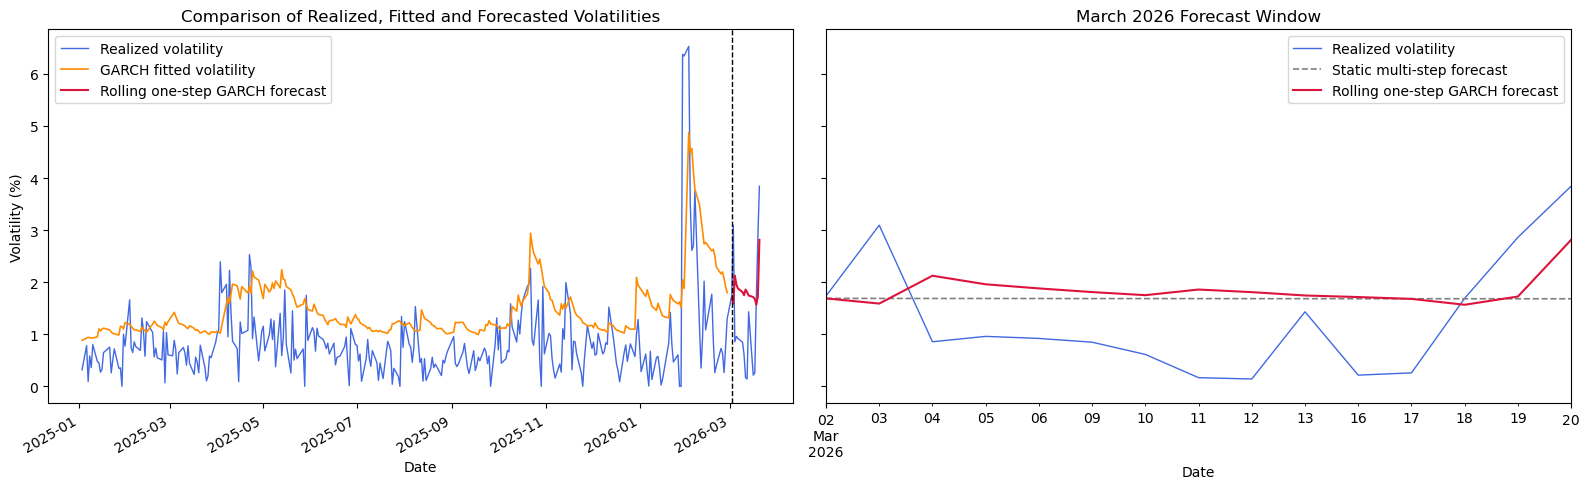

In [161]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

realized_vol.plot(ax=axes[0], color="royalblue", linewidth=1.0, label="Realized volatility")
vol_train_fitted.plot(ax=axes[0], color="darkorange", linewidth=1.2, label="GARCH fitted volatility")
vol_forecast_mean.plot(ax=axes[0], color="crimson", linewidth=1.5, label="Rolling one-step GARCH forecast")
axes[0].axvline(test_start, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Comparison of Realized, Fitted and Forecasted Volatilities")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Volatility (%)")
axes[0].legend()

vol_test_realized.plot(ax=axes[1], color="royalblue", linewidth=1.0, label="Realized volatility")
static_forecast_mean.plot(ax=axes[1], color="grey", linewidth=1.2, linestyle="--", label="Static multi-step forecast")
vol_forecast_mean.plot(ax=axes[1], color="crimson", linewidth=1.5, label="Rolling one-step GARCH forecast")
axes[1].set_title("March 2026 Forecast Window")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()


**Response**: The forecast is now computed using a rolling one-step-ahead procedure instead of a single multi-step forecast from the end of February 2026. This means the GARCH model is re-estimated before each March 2026 trading day, so the red line can react to newly observed returns instead of immediately drifting toward a nearly constant long-run volatility level.

The printed table now reports both the old static baseline and the rolling one-step test error. In this setup, the rolling forecast is less flat and slightly more responsive, although very abrupt volatility spikes can still remain difficult for a standard daily `GARCH(1,1)` model to anticipate. Note that for a standard one-step-ahead GARCH variance forecast, the conditional variance is deterministic given today's information, so a simulation-based confidence band is not informative and is therefore omitted here.
